In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
from matplotlib.patches import Circle

In [6]:
# o for originals
o = np.load('true_grid_images.npy')
print(o.shape)
# r for reconstructions
r = np.load('decoded_images_square.npy')
print(r.shape)

(6, 6, 30, 30)
(6, 6, 30, 30)


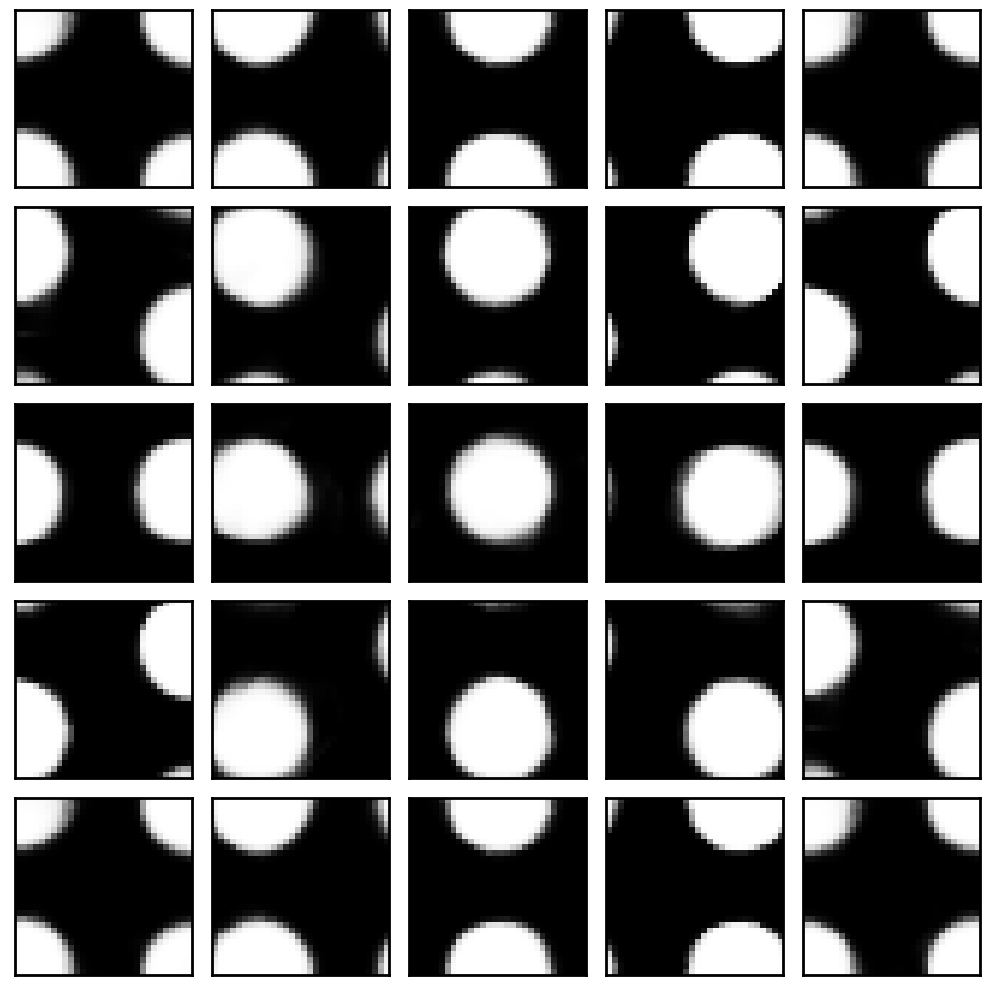

In [73]:
n = 5

fig = plt.figure(figsize=(10,10))
ax = fig.subplots(n,n)

for i in range(0,n):
    for j in range(0,n):
        ax[i,j].imshow(r[i,j,:,:], 
                        cmap='gray')
        ax[i,j].axes.get_xaxis().set_ticks([])
        ax[i,j].axes.get_yaxis().set_ticks([])
        for spine in ax[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(2)
            
#for i in range(0,n):
#    for j in range(0,n):
#        ax[i,n+j].imshow(r[i,j,:,:], 
#                        cmap='gray')
#        ax[i,n+j].axes.get_xaxis().set_ticks([])
#        ax[i,n+j].axes.get_yaxis().set_ticks([])
#        for spine in ax[i,n+j].spines.values():
#            spine.set_edgecolor('black')
#            spine.set_linewidth(2)
        
fig.tight_layout()
fig.savefig('reconstructed-circles.png', dpi=300, bbox_inches='tight')

In [38]:
d2 = np.load('diagrams_Z2.npz')
diagrams2 = [d2['h0'],d2['h1'],d2['h2']]

d3 = np.load('diagrams_Z3.npz')
diagrams3 = [d3['h0'],d3['h1'],d3['h2']]

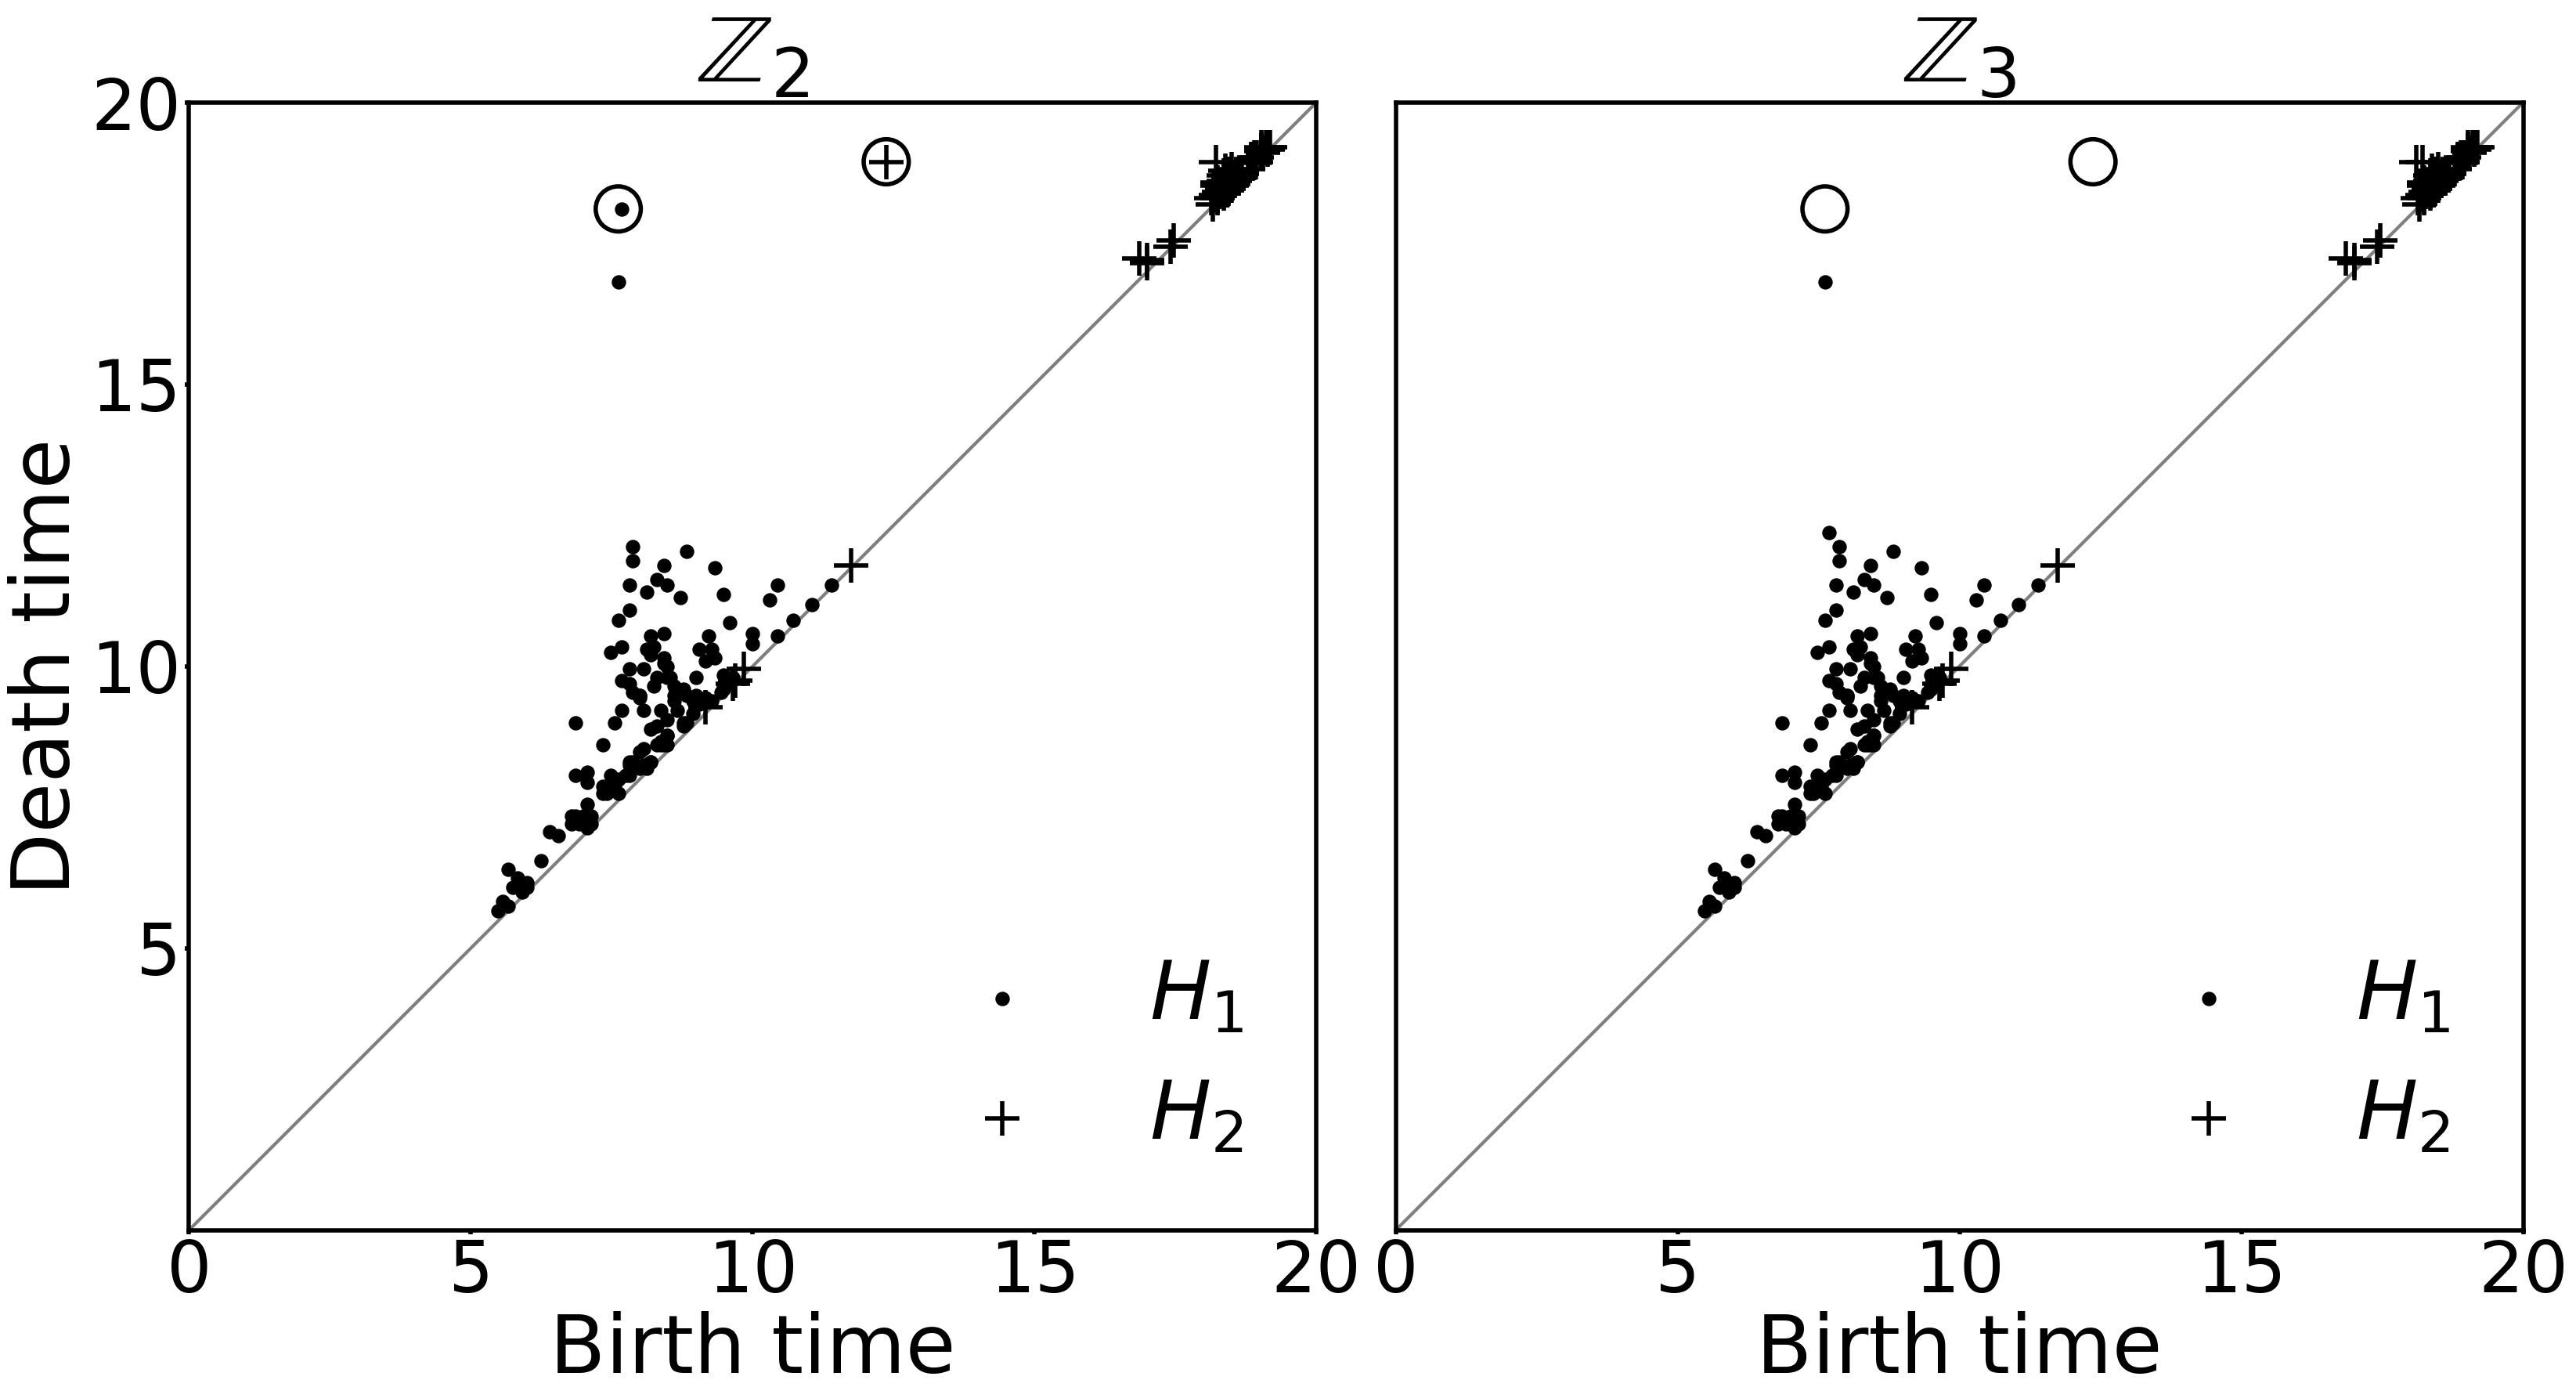

In [66]:
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(33, 20))

dot_size = 600
square_size = 1000
circle_radius = 0.08*5
large_font_size = 75
small_font_size = 65
subtitle_font_size = 90

#fig.subplots_adjust(bottom=0.01, right=0.02, top=0.02, left=0.01)

#fig.suptitle('Horizontally stacked subplots')

#ax2.scatter(diagrams2[0][:,0], diagrams2[0][:,1], marker = "_", color='black')
ax2.scatter(diagrams2[1][:,0], diagrams2[1][:,1], marker = ".", 
            color='black', alpha=1, s=dot_size, label='$H_1$')
ax2.scatter(diagrams2[2][:,0], diagrams2[2][:,1], marker = "+",linewidths=4,
            color='black', alpha=1, s=square_size, label='$H_2$')
ax2.set_xticks([0,5,10,15,20])
ax2.tick_params(axis='both', which='major', labelsize=small_font_size)
ax2.set_xlabel('Birth time', fontsize=large_font_size)
ax2.set_yticks([5,10,15,20])
ax2.set_ylabel('Death time', fontsize=large_font_size)
ax2.plot(np.linspace(0,20,100), np.linspace(0,20,100), color='black', alpha=0.5, linewidth=3)
ax2.set_aspect(1)
ax2.legend(loc='lower right', prop={'size': large_font_size}, frameon=False)
ax2.set_title('$\mathbb{Z}_2$', fontsize=subtitle_font_size)

ax2.set_xlim((0,20))
ax2.set_ylim((0,20))

for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(4)

# increase tick width
ax2.tick_params(width=4)

lifetimes22 = diagrams2[2][:,1]-diagrams2[2][:,0]
ax2.add_patch(Circle((diagrams2[2][np.argsort(lifetimes22)[-1],0], 
              diagrams2[2][np.argsort(lifetimes22)[-1],1]),
             radius=circle_radius, edgecolor='black', fill=False, linewidth=4))



lifetimes21 = diagrams2[1][:,1]-diagrams2[1][:,0]
ax2.add_patch(Circle((diagrams2[1][np.argsort(lifetimes21)[-2],0], 
              diagrams2[1][np.argsort(lifetimes21)[-1],1]),
             radius=circle_radius, edgecolor='black', fill=False, linewidth=4))




#ax3.scatter(diagrams3[0][:,0], diagrams3[0][:,1])
ax3.scatter(diagrams3[1][:,0], diagrams3[1][:,1], marker = ".", 
            color='black', alpha=1, s=dot_size, label='$H_1$')
ax3.scatter(diagrams3[2][:,0], diagrams3[2][:,1], marker = "+",linewidths=4, 
            color='black', alpha=1, s=square_size, label='$H_2$')
ax3.set_xlabel('Birth time', fontsize=large_font_size)
ax3.tick_params(axis='both', which='major', labelsize=small_font_size)
ax3.plot(np.linspace(0,21,100), np.linspace(0,21,100), color='black', alpha=0.5, linewidth=3)
ax3.set_xticks([0,5,10,15,20])
ax3.set_yticks([])
ax3.set_aspect(1)
ax3.legend(loc='lower right', prop={'size': large_font_size}, frameon=False)
ax3.set_title('$\mathbb{Z}_3$', fontsize=subtitle_font_size)

#lifetimes32 = diagrams3[2][:,1]-diagrams3[2][:,0]


ax3.add_patch(Circle((diagrams2[2][np.argsort(lifetimes22)[-1],0], 
              diagrams2[2][np.argsort(lifetimes22)[-1],1]),
             radius=circle_radius, edgecolor='black', fill=False, linewidth=4))

#lifetimes32 = diagrams3[1][:,1]-diagrams3[1][:,0]


ax3.add_patch(Circle((diagrams2[1][np.argsort(lifetimes21)[-2],0], 
              diagrams2[1][np.argsort(lifetimes21)[-1],1]),
             radius=circle_radius, edgecolor='black', fill=False, linewidth=4))

ax3.set_xlim((0,20))
ax3.set_ylim((0,20))

for axis in ['top','bottom','left','right']:
    ax3.spines[axis].set_linewidth(4)

# increase tick width
ax3.tick_params(width=4)



fig.tight_layout()

#fig.show()

fig.savefig('diagrams-of-decoded-circles.png', dpi=300, bbox_inches='tight')